# Linear Regression

Step 1, import the things we probably always want

In [1]:
import numpy as np # numpy is for numerical computing
import matplotlib.pyplot as plt # pyplot is for plotting graphs

import pandas as pd # pandas is for data analysis and manipulation

These ones are not for always, but I like this plotting style for this workbook

In [2]:
import matplotlib # matplotlib is for customizing the plots
matplotlib.style.use('ggplot') # ggplot is a popular style for plotting graphs

Let's take this set

X has values 5,7,9,11,13,15

y has 11,14,20,24,29,31

and we want to build a model
$\hat{y} = w_0 + w_1x$

In [3]:
X = np.array([5, 7, 9, 11, 13, 15]) # independent variable
y = np.array([11, 14, 20, 24, 29, 31]) # dependent variable

Let's plot it to see if a linear model makes sense for this

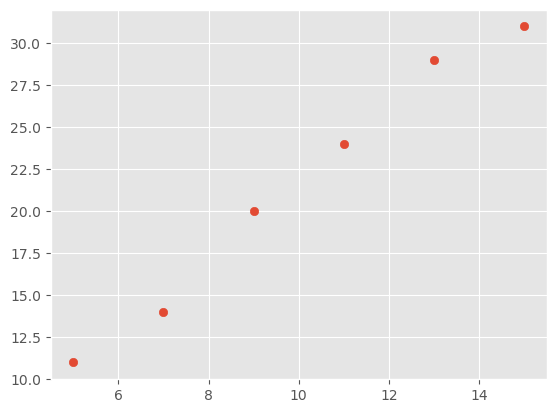

In [4]:
plt.scatter(X,y) # scatter plot of the data points
plt.show() # display the plot

We can check the correlation coefficient 

In [5]:
np.corrcoef(X, y) # calculate the correlation coefficient between X and y

array([[1.        , 0.99322298],
       [0.99322298, 1.        ]])

0.99322, very high correlation!

## Data Structure: let's look at X and y in more detail

In [6]:
y.shape # check the shape of the dependent variable array. Shape is a tuple that represents the dimensions of the array. In this case, it should return (6,) indicating that y is a 1-dimensional array with 6 elements.

(6,)

In [7]:
y.ndim # check the number of dimensions of the dependent variable array. In this case, it should return 1 indicating that y is a 1-dimensional array.

1

y is clearly a 1d array, as expected - good

In [8]:
X.shape # check the shape of the independent variable array. Shape is a tuple that represents the dimensions of the array. In this case, it should return (6,) indicating that X is a 1-dimensional array with 6 elements.

(6,)

In [9]:
X.ndim # check the number of dimensions of the independent variable array. In this case, it should return 1 indicating that X is a 1-dimensional array.

1

X is also a 1d array, not good. It needs to be a 2d array

In [10]:
X # check the values of the independent variable array. In this case, it should return the array [5, 7, 9, 11, 13, 15] indicating that X contains 6 elements.

array([ 5,  7,  9, 11, 13, 15])

It's written as one row, but really we need 6 rows with one entry in each row. Let's reshape the array

In [11]:
X = X.reshape(-1,1) # reshape the independent variable array to be a 2-dimensional array with 6 rows and 1 column. The -1 indicates that the number of rows should be inferred from the length of the array, and the 1 indicates that there should be 1 column. This is necessary for scikit-learn's LinearRegression model, which expects a 2-dimensional array for the independent variable.

In [12]:
X.shape # check the shape of the independent variable array. Shape is a tuple that represents the dimensions of the array. In this case, it should return (6, 1) indicating that X is a 2-dimensional array with 6 rows and 1 column.

(6, 1)

In [13]:
X.ndim # check the number of dimensions of the independent variable array. In this case, it should return 2 indicating that X is a 2-dimensional array.

2

2d array. Good. Let's look at it

In [14]:
X # display the independent variable array

array([[ 5],
       [ 7],
       [ 9],
       [11],
       [13],
       [15]])

6 rows now

## Section 3, build the model

In [15]:
from sklearn.linear_model import LinearRegression # import the LinearRegression class from the sklearn.linear_model module. This class is used to create a linear regression model that can be trained on the data and used to make predictions.

Question mark is used to display the documentation of the LinearRegression class. It will show the parameters, attributes, and methods of the class, as well as a brief description of what the class does.

In [16]:
LinearRegression?

Init signature:
LinearRegression(
    *,
    fit_intercept=True,
    copy_X=True,
    tol=1e-06,
    n_jobs=None,
    positive=False,
)
Docstring:     
Ordinary least squares Linear Regression.

LinearRegression fits a linear model with coefficients w = (w1, ..., wp)
to minimize the residual sum of squares between the observed targets in
the dataset, and the targets predicted by the linear approximation.

Parameters
----------
fit_intercept : bool, default=True
    Whether to calculate the intercept for this model. If set
    to False, no intercept will be used in calculations
    (i.e. data is expected to be centered).

copy_X : bool, default=True
    If True, X will be copied; else, it may be overwritten.

tol : float, default=1e-6
    The precision of the solution (`coef_`) is determined by `tol` which
    specifies a different convergence criterion for the `lsqr` solver.
    `tol` is set as `atol` and `btol` of `scipy.sparse.linalg.lsqr` when
    fitting on sparse training data. Th

Create the model, with sklearn you initialise the model with an "empty constructor" of the base form of the model. LinearRegression is the constructor

In [17]:
model = LinearRegression()

It means something very simple:
When you use scikit-learn (sklearn), you first create an empty model object before giving it your data.

For example:

**from sklearn.linear_model import LinearRegression**

**model = LinearRegression()**

Here:

*LinearRegression* = the constructor/class used to create a linear regression model.
*LinearRegression()* = creates a new, empty model.
*model* = the object you will use to train and make predictions.

Think of it like buying an empty calculator:

**model = LinearRegression()**

At this point, the model hasn't learned anything yet.

Then you give it your training data:

**model.fit(X, y)**

Now the model learns the relationship between X (input/features) and y (target).

Finally:

**predictions = model.predict(X_test)**

It uses what it learned to make predictions.

Now "fit" the model using X and y. Use an appropriate ? after method name to see. .fit expects the X part to be a matrix, but we have a 1 dimensional array. Pay attention to the error message when you just do x,y

In [18]:
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Section 4 Inferences

In [19]:
model.coef_ # model.coef_ is an attribute of the LinearRegression class that returns the coefficients of the linear regression model. In this case, it should return an array with a single value indicating the slope of the line that best fits the data.

array([2.12857143])

In [20]:
model.intercept_ # model.intercept_ is an attribute of the LinearRegression class that returns the intercept of the linear regression model. In this case, it should return a single value indicating the y-intercept of the line that best fits the data.

np.float64(0.2142857142857153)

There are the parameters

$\hat{y} = 0.2142857142857153 + 2.12857143 x$

is the model

In [21]:
w0 = model.intercept_ # w0 is the y-intercept of the linear regression model, which is the value of y when X is 0. It represents the point where the line crosses the y-axis.
w1 = model.coef_[0] # w1 is the coefficient of the linear regression model, which is the slope of the line that best fits the data.

In [22]:
predictions = w0 + np.dot(w1,X).reshape(1,-1) # predictions is an array that contains the predicted values of y based on the linear regression model. It is calculated by taking the dot product of the slope (w1) and the independent variable array (X), and adding the y-intercept (w0). The reshape(1,-1) is used to ensure that the resulting array has the correct shape for plotting.

Dot product [pl. **iloczyn skalarny**] in simple terms

Suppose:

x = [1, 2, 3]
y = [4, 5, 6]

The dot product is:

$$ x \cdot y = (1\times4) + (2\times5) + (3\times6) $$

So:

4+10+18=32

In [23]:
predictions # display the predicted values of y based on the linear regression model. In this case, it should return an array with 6 elements indicating the predicted values of y for each value of X.

array([[10.85714286, 15.11428571, 19.37142857, 23.62857143, 27.88571429,
        32.14285714]])

Using the built in .predict

In [24]:
pred = model.predict(X) # This is the same as the previous cell, but using the predict method of the LinearRegression class. It takes the independent variable array (X) as input and returns an array of predicted values of y based on the linear regression model.

In [25]:
pred # display the predicted values of y based on the linear regression model using the predict method. In this case, it should return an array with 6 elements indicating the predicted values of y for each value of X.

array([10.85714286, 15.11428571, 19.37142857, 23.62857143, 27.88571429,
       32.14285714])

In [26]:
pred == predictions # check if the predicted values of y based on the linear regression model using the predict method are equal to the predicted values of y based on the linear regression model calculated manually. In this case, it should return an array with 6 elements indicating whether each predicted value is equal or not.    

array([[ True,  True,  True,  True,  True,  True]])

They're the same.

## Section 5 Evaluation

In [27]:
from sklearn.metrics import mean_squared_error as mse # import the mean_squared_error function from the sklearn.metrics module. This function is used to calculate the mean squared error between the predicted values and the actual values of y. The mean squared error is a measure of how well the linear regression model fits the data, with lower values indicating a better fit.
from sklearn.metrics import r2_score as r2 # import the r2_score function from the sklearn.metrics module. This function is used to calculate the R-squared value between the predicted values and the actual values of y. The R-squared value is a measure of how well the linear regression model fits the data, with higher values indicating a better fit.
from sklearn.metrics import root_mean_squared_error as rms # import the root_mean_squared_error function from the sklearn.metrics module. This function is used to calculate the root mean squared error between the predicted values and the actual values of y. The root mean squared error is a measure of how well the linear regression model fits the data, with lower values indicating a better fit.

In [28]:
mse(y,pred) # calculate the mean squared error between the actual values of y and the predicted values of y based on the linear regression model. In this case, it should return a single value indicating the mean squared error.

0.723809523809522

In [29]:
r2(y,pred) # calculate the R-squared value between the actual values of y and the predicted values of y based on the linear regression model. In this case, it should return a single value indicating the R-squared value.

0.9864918906909576

Very close to 1!

In [30]:
rms(y,pred) # calculate the root mean squared error between the actual values of y and the predicted values of y based on the linear regression model. In this case, it should return a single value indicating the root mean squared error.

0.8507699593953244

In [31]:
rmse = np.sqrt(mse(y,pred)) # calculate the root mean squared error between the actual values of y and the predicted values of y based on the linear regression model. In this case, it should return a single value indicating the root mean squared error. This is done by taking the square root of the mean squared error calculated in the previous cell.

In [32]:
rmse # display the root mean squared error between the actual values of y and the predicted values of y based on the linear regression model. In this case, it should return a single value indicating the root mean squared error.

np.float64(0.8507699593953244)

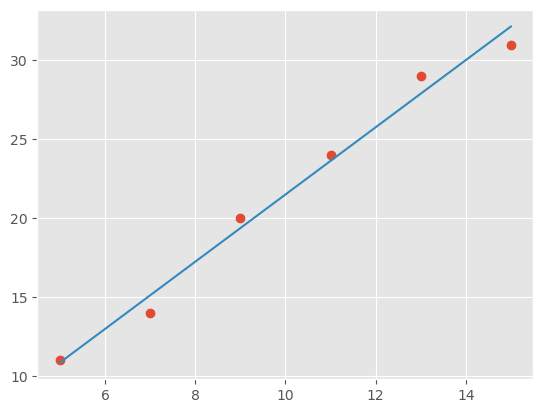

In [33]:
plt.plot(X,y,'o') # plot the actual values of y against the independent variable array (X) as a scatter plot with 'o' markers.
plt.plot(X,pred) # plot the predicted values of y against the independent variable array (X) as a line plot. This will show how well the linear regression model fits the data.
plt.show() # display the plot with the actual values of y and the predicted values of y based on the linear regression model. This will show how well the linear regression model fits the data.

shows the line of best fit

In [34]:
model.score(X,y) # calculate the R-squared value between the actual values of y and the predicted values of y based on the linear regression model using the score method of the LinearRegression class. In this case, it should return a single value indicating the R-squared value.

0.9864918906909576

Agrees with the r2 from above

## Simple linear regression with automobile data
We will now use sklearn to predict automobile milesage per gallon (mpg) and evaluate these predictions. We first load the data and split them into a training set and a testing set.

In [35]:
#load mtcars
dfcars=pd.read_csv("mtcars.csv") # load the mtcars dataset from a CSV file into a pandas DataFrame called dfcars. The mtcars dataset contains information about various car models, including their weight, horsepower, and fuel efficiency (miles per gallon). The read_csv function is used to read the CSV file and create the DataFrame.
dfcars=dfcars.rename(columns={"Unnamed: 0":"name"}) # rename the column "Unnamed: 0" in the dfcars DataFrame to "name". This is done to give the column a more meaningful name, as it contains the names of the car models in the dataset.
dfcars.head(10) # display the first 10 rows of the dfcars DataFrame. The head function is used to show a specified number of rows from the top of the DataFrame, which in this case is 10. This allows us to see a sample of the data in the mtcars dataset, including the car names, weight, horsepower, and fuel efficiency (miles per gallon).

,name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


We need to choose the variables that we think will be good predictors for the dependent variable `mpg`. 

>**EXERCISE:**  Pick one variable to use as a predictor for simple linear regression.  Create a markdown cell below and discuss your reasons.  You may want to justify this with some visualizations.  Is there a second variable you'd like to use as well, say for multiple linear regression with two predictors?

#### Choosing predictors for MPG

For the simple linear regression model, I will use **wt (weight)** as the predictor
variable and **mpg (miles per gallon)** as the response variable.

I chose `wt` because there appears to be a strong relationship between the weight
of a car and its fuel efficiency. In general, heavier cars require more energy to
move, so they tend to have lower MPG. A scatter plot of `wt` against `mpg` can be
used to visualise this relationship.

For multiple linear regression, I would also consider adding **hp (horsepower)**.
Horsepower represents the power of the engine and may also be related to fuel
efficiency. Using both `wt` and `hp` may allow the model to explain more of the
variation in MPG than using weight alone.

Therefore:

- **Response variable:** `mpg`
- **First predictor:** `wt`
- **Second predictor:** `hp`

The simple linear regression model will be:

`mpg ~ wt`

The multiple linear regression model will be:

`mpg ~ wt + hp`

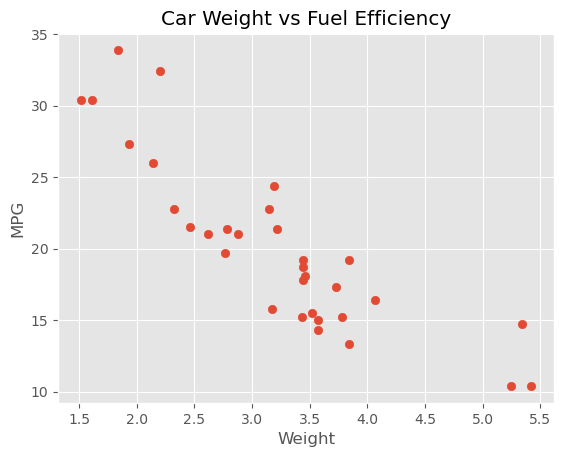

In [36]:
# Scatter plot of car weight vs fuel efficiency

plt.scatter(dfcars['wt'], dfcars['mpg'])
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.title('Car Weight vs Fuel Efficiency')
plt.show()


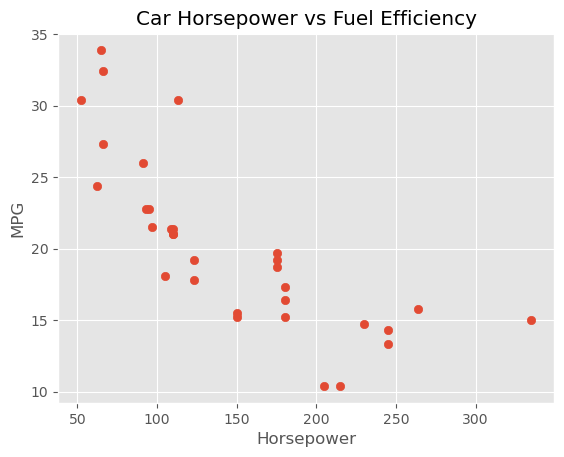

In [37]:
# Scatter plot of car horsepower vs fuel efficiency

plt.scatter(dfcars['hp'], dfcars['mpg'])
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Car Horsepower vs Fuel Efficiency')
plt.show()

In [38]:
# Correlation matrix of mpg, wt, and hp

dfcars[['mpg', 'wt', 'hp']].corr()

,mpg,wt,hp
mpg,1.000000,-0.867659,-0.776168
wt,-0.867659,1.000000,0.658748
hp,-0.776168,0.658748,1.000000


> **EXERCISE:** With sklearn fit the training data using simple linear regression. 

> Plot the data and the prediction.  

>Print out the mean squared error for the set

In [39]:
# define predictor and response for set

X = dfcars[['wt']]
y = dfcars['mpg']

In [40]:
X # display X which is the independent variable array containing the weight of the cars. This will be used as the predictor in the linear regression model.

,wt
0,2.620
1,2.875
2,2.320
3,3.215
4,3.440
5,3.460
6,3.570
7,3.190
8,3.150
9,3.440


In [41]:
y # Display y which is the dependent variable array containing the fuel efficiency (miles per gallon) of the cars. This will be used as the response in the linear regression model.

0     21.0
1     21.0
2     22.8
3     21.4
4     18.7
5     18.1
6     14.3
7     24.4
8     22.8
9     19.2
10    17.8
11    16.4
12    17.3
13    15.2
14    10.4
15    10.4
16    14.7
17    32.4
18    30.4
19    33.9
20    21.5
21    15.5
22    15.2
23    13.3
24    19.2
25    27.3
26    26.0
27    30.4
28    15.8
29    19.7
30    15.0
31    21.4
Name: mpg, dtype: float64

In [42]:
X = np.array(dfcars['wt']) # np.array() is a function from the NumPy library that creates a NumPy array from the input data. In this case, it is used to convert the 'wt' column of the dfcars DataFrame into a NumPy array, which will be used as the independent variable (predictor) in the linear regression model.
y = np.array(dfcars['mpg']) # np.array() is a function from the NumPy library that creates a NumPy array from the input data. In this case, it is used to convert the 'mpg' column of the dfcars DataFrame into a NumPy array, which will be used as the dependent variable (response) in the linear regression model.

In [43]:
y.shape # check the shape of the dependent variable array

(32,)

In [44]:
y.ndim # check the number of dimensions of the dependent variable array. 

1

In [45]:
X.shape # check the shape of the independent variable array. 

(32,)

In [46]:
X.ndim # check the number of dimensions of the independent variable array.

1

In [47]:
X = X.reshape(-1,1) # reshape the independent variable array to be a 2-dimensional array 

In [48]:
X.shape # check the shape of the independent variable array.

(32, 1)

In [49]:
X # display the independent variable array

array([[2.62 ],
       [2.875],
       [2.32 ],
       [3.215],
       [3.44 ],
       [3.46 ],
       [3.57 ],
       [3.19 ],
       [3.15 ],
       [3.44 ],
       [3.44 ],
       [4.07 ],
       [3.73 ],
       [3.78 ],
       [5.25 ],
       [5.424],
       [5.345],
       [2.2  ],
       [1.615],
       [1.835],
       [2.465],
       [3.52 ],
       [3.435],
       [3.84 ],
       [3.845],
       [1.935],
       [2.14 ],
       [1.513],
       [3.17 ],
       [2.77 ],
       [3.57 ],
       [2.78 ]])

In [50]:
# create linear regression object with sklearn

model = LinearRegression() # model is an instance of the LinearRegression class from the sklearn.linear_model module. This object will be used to fit the linear regression model to the data and make predictions.

# train the model and make predictions

model.fit(X,y) # train the linear regression model using the fit method of the LinearRegression class. This method takes the independent variable array (X) and the dependent variable array (y) as input and fits the linear regression model to the data.

pred = model.predict(X) # pred is an array that contains the predicted values of y based on the linear regression model using the predict method of the LinearRegression class. This method takes the independent variable array (X) as input and returns an array of predicted values of y based on the linear regression model.

pred # display the predicted values of y based on the linear regression model using the predict method. In this case, it should return an array with 32 elements indicating the predicted values of y for each value of X.


array([23.28261065, 21.9197704 , 24.88595212, 20.10265006, 18.90014396,
       18.79325453, 18.20536265, 20.23626185, 20.45004071, 18.90014396,
       18.90014396, 15.53312687, 17.3502472 , 17.08302362,  9.22665041,
        8.29671236,  8.71892561, 25.52728871, 28.65380458, 27.47802083,
       24.11100374, 18.47258623, 18.92686632, 16.76235533, 16.73563297,
       26.94357367, 25.847957  , 29.19894068, 20.34315128, 22.48093991,
       18.20536265, 22.4274952 ])

In [51]:
#print out coefficients

print("Coefficient:", model.coef_) # model.coef_ is an attribute of the LinearRegression class that returns the coefficients of the linear regression model. In this case, it should return an array with a single value indicating the slope of the line that best fits the data.
print("Intercept:", model.intercept_) # model.intercept_ is an attribute of the LinearRegression class that returns the intercept of the linear regression model. In this case, it should return a single value indicating the y-intercept of the line that best fits the data.

Coefficient: [-5.34447157]
Intercept: 37.28512616734204


In [52]:
# R-squared value
r2(y,pred) # calculate the R-squared value between the actual values of y and the predicted values of y based on the linear regression model. In this case, it should return a single value indicating the R-squared value. 

0.7528327936582646

In [53]:
# R-squared value using model.score method
model.score(X,y)

0.7528327936582646

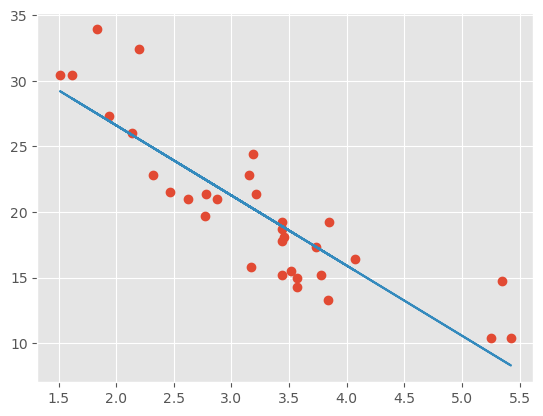

In [54]:
# Plot outputs

plt.plot(X,y,'o') # plot the actual values of y against the independent variable array (X) as a scatter plot with 'o' markers.
plt.plot(X,pred) # plot the predicted values of y against the independent variable array (X) as a line plot. This will show how well the linear regression model fits the data.
plt.show()


# Diabetes Dataset - Multiple linear regression 

Now we are going to fit the training data (from the diabetes dataset built into sklearn) using multiple linear regression with multiple predictors. 

In [55]:
from sklearn import datasets
diabetes = datasets.load_diabetes()
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


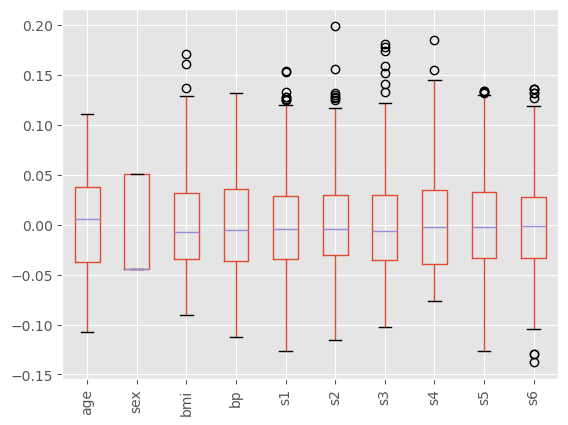

In [56]:
data = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
data.boxplot(rot=90)
data.head()

Above I put the data into a pandas dataframe and then tried to visualise it. You will notice all of the data is in a similar range

### Normalised data
They all have a mean of 0 and standard deviation of 1. This is called Normalising the data and is a common step that I'll get into later on.

The obvious one you'll notice is the sex variable. This has two options which are 0.050680 or -0.044642, when usually with 2 options we would go with 0 and 1. The numbers were changed due to this normalisation

In [57]:
X = data 
y = diabetes.target

In [58]:
lr = LinearRegression()

In [59]:
lr.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
r_squared = lr.score(X,y)
r_squared

0.5177484222203498

Let's do a slightly different r2

In [61]:
adjusted_r_squared = 1 - (1-r_squared)*(len(y)-1)/(len(y)-X.shape[1]-1)
adjusted_r_squared

0.5065592904853231

In [62]:
lr.coef_

array([ -10.0098663 , -239.81564367,  519.84592005,  324.3846455 ,
       -792.17563855,  476.73902101,  101.04326794,  177.06323767,
        751.27369956,   67.62669218])

In [63]:
lr.intercept_

np.float64(152.13348416289597)

Text(0, 0.5, 'Coefficient')

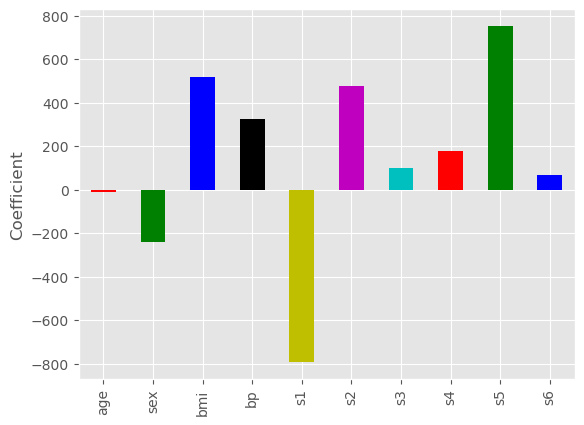

In [64]:
coef=pd.Series(lr.coef_ , index=diabetes.feature_names)
coef.plot(kind='bar', color = list('rgbkymc'))
plt.ylabel('Coefficient')

Some of those coefficients are very large, and it looks like age does not contribute as much as the others

The very large coefficients can often be problematic so we'll have to think about this one again later

Maybe removing age will give us a better model

We don't really have enough knowledge to figure it out. It's possible you would get a better model without age, s3, s4 and s6